<a href="https://colab.research.google.com/github/uchegreat/sms-spam-detection/blob/upload-project/ML_ASSGN2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

PLANNING AND DATASET COLLECTION

In [ ]:
from google.colab import files
uploaded = files.upload()


Saving spam.csv to spam.csv


In [ ]:
import pandas as pd
data = pd.read_csv('spam.csv', encoding='latin-1')
data.head()


,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


IMPORT AND INSTALL REQUIRED LIBARIES



In [ ]:
!pip install nltk
import pandas as pd
import numpy as np
import re
import nltk

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

nltk.download('stopwords')
nltk.download('wordnet')


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


True

LOAD AND PREPARE DATASETS

In [ ]:
df = pd.read_csv("spam.csv", encoding='latin-1')
df = df[['v1', 'v2']].copy()
df.columns = ['label', 'message']
df['label_num'] = df['label'].map({'ham': 0, 'spam': 1})#




CLEANSING THE TEXT DATA

In [ ]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = re.sub(r'\W', ' ', text)
    text = text.lower()
    words = text.split()
    words = [lemmatizer.lemmatize(word) for word in words if word not in stop_words]
    return ' '.join(words)

df['cleaned_message'] = df['message'].apply(clean_text)


FEATURE EXTRACTION USING TF-IDF

In [ ]:
vectorizer = TfidfVectorizer(max_features=3000)
X = vectorizer.fit_transform(df['cleaned_message'])
y = df['label_num']


TRAINING THE MODEL

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestClassifier()
model.fit(X_train, y_train)


RandomForestClassifier()

EVALUATE THE MODEL

In [ ]:
y_pred = model.predict(X_test)
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))


[[964   1]
 [ 21 129]]
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       965
           1       0.99      0.86      0.92       150

    accuracy                           0.98      1115
   macro avg       0.99      0.93      0.96      1115
weighted avg       0.98      0.98      0.98      1115



VISUALIZATION OF THE MODEL

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report


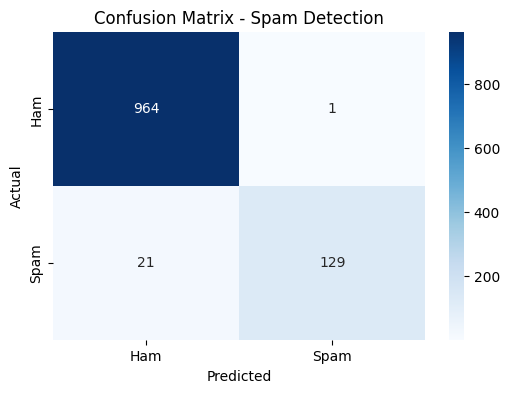

In [ ]:
# Predict labels
y_pred = model.predict(X_test)

# Generate confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot the confusion matrix heatmap
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Spam Detection')
plt.show()


In [ ]:
print(classification_report(y_test, y_pred, target_names=['Ham', 'Spam']))


              precision    recall  f1-score   support

         Ham       0.98      1.00      0.99       965
        Spam       0.99      0.86      0.92       150

    accuracy                           0.98      1115
   macro avg       0.99      0.93      0.96      1115
weighted avg       0.98      0.98      0.98      1115



BAR CHARTS OF MODEL PERFORMANCE

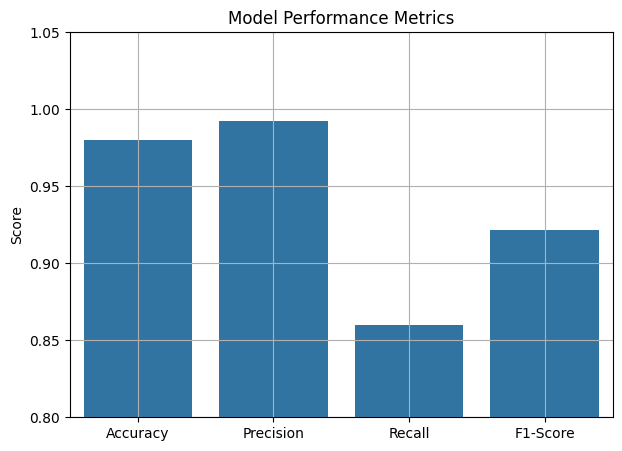

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Create a bar chart
metrics = [accuracy, precision, recall, f1]
labels = ['Accuracy', 'Precision', 'Recall', 'F1-Score']

plt.figure(figsize=(7,5))
sns.barplot(x=labels, y=metrics)
plt.ylim(0.8, 1.05)
plt.title('Model Performance Metrics')
plt.ylabel('Score')
plt.grid(True)
plt.show()


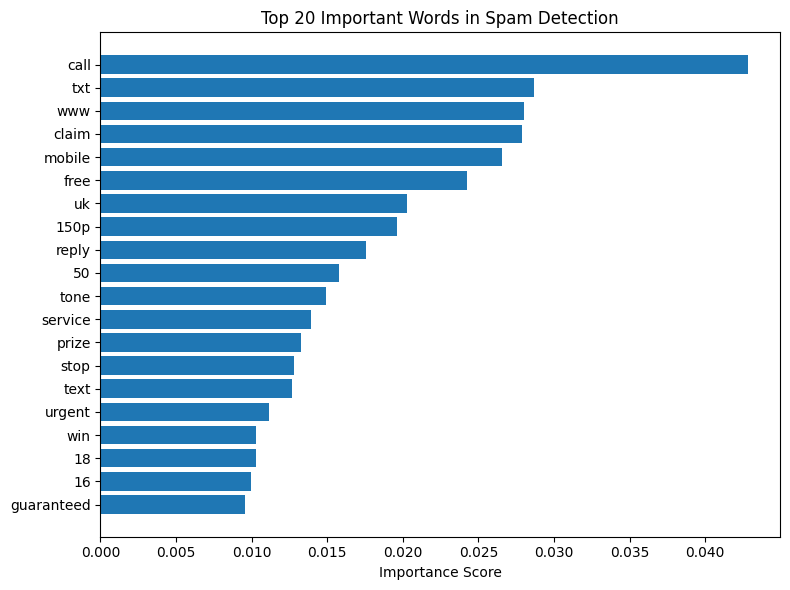

In [ ]:
# Get feature importance
import numpy as np

importances = model.feature_importances_
feature_names = vectorizer.get_feature_names_out()
indices = np.argsort(importances)[-20:]  # top 20

# Plot
plt.figure(figsize=(8,6))
plt.title('Top 20 Important Words in Spam Detection')
plt.barh(range(len(indices)), importances[indices], align='center')
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()


MANUAL TESTING OF THE MODEL

In [ ]:
# Example custom message
custom_message = ["Congratulations! You've won a free iPhone. Click here to claim."]

# Clean the custom message using the same function
cleaned = [clean_text(msg) for msg in custom_message]

# Convert to vector using the trained TF-IDF vectorizer
vectorized = vectorizer.transform(cleaned)

# Predict using the trained model
prediction = model.predict(vectorized)

# Show result
print("Prediction:", "Spam" if prediction[0] == 1 else "Ham")


Prediction: Ham


SIMPLE TESTING INPUT

In [ ]:
message = input("Enter your message: ")
cleaned = clean_text(message)
vectorized = vectorizer.transform([cleaned])
prediction = model.predict(vectorized)
print("Prediction:", "Spam" if prediction[0] == 1 else "Ham")


Enter your message: click this link to claim 10,000pounds
Prediction: Spam
